# Using the *Entity Tile* to compare a performance pointed in ROC with the no-skill performances

In [1]:
%matplotlib tk

import matplotlib.pyplot as plt
from matplotlib.widgets import CheckButtons, Slider

from sorbetto.annotation import (
    AnnotationCurveFixedClassPriors,
    AnnotationGridShiftClassPriors,
    AnnotationImportanceCompass,
)
from sorbetto.flavor import EntityFlavor
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.performance import TwoClassClassificationPerformance
from sorbetto.ranking import Entity
from sorbetto.tile import EntityTile

## Configuration

In [2]:
initial_prior_pos = 0.5
initial_fpr = 0.1
initial_tpr = 0.9

## The data

In [3]:
# We will use the default parameterization for drawing the Tile
parameterization = ParameterizationDefault()

prior_pos = None
prior_neg = None
fpr = None
tpr = None

e_no_skill_neg = None
e_no_skill_pos = None

annotation_curve = None
annotation_grid = None
annotation_compass = AnnotationImportanceCompass(color="k")

should_redraw_all = False

opposite_classifier_visible = False
draw_annotation_grid = False
draw_annotation_compass = False

## The setters

In [4]:
def set_prior_pos(value_prior_pos):
    # print ( 'setting prior pos to', value_prior_pos )

    global prior_pos
    global prior_neg
    global e_no_skill_neg
    global e_no_skill_pos
    global annotation_curve
    global annotation_grid

    prior_pos = value_prior_pos
    prior_neg = 1.0 - prior_pos
    p_no_skill_neg = TwoClassClassificationPerformance.getNoSkill(
        priorPos=prior_pos, ratePos=0.0
    )
    p_no_skill_pos = TwoClassClassificationPerformance.getNoSkill(
        priorPos=prior_pos, ratePos=1.0
    )
    e_no_skill_neg = Entity(p_no_skill_neg, r"$\mathcal{C}_-$", color="lightsalmon")
    e_no_skill_pos = Entity(p_no_skill_pos, r"$\mathcal{C}_+$", color="lightgreen")
    annotation_curve = AnnotationCurveFixedClassPriors(
        prior_pos, color="k", linestyle=":"
    )
    annotation_grid = AnnotationGridShiftClassPriors(
        prior_pos_old=0.5, prior_pos_new=prior_pos, linestyle="-", color="w"
    )


def set_fpr_tpr(value_fpr, value_tpr):
    # print ( 'setting fpr to', value_fpr )
    # print ( 'setting tpr to', value_tpr )

    global fpr
    global tpr

    fpr = value_fpr
    tpr = value_tpr

## Create figure

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
plt.subplots_adjust(bottom=0.25)  # leave space for the widgets

prior_pos_ax = fig.add_axes([0.6, 0.1, 0.3, 0.03])  # left, bottom, width, height
prior_pos_slider = Slider(
    ax=prior_pos_ax,
    label=r"$\pi_+ = P(Y=c_+)$",
    valmin=0.0,
    valmax=1.0,
    valinit=initial_prior_pos,
    valstep=0.01,
    orientation="horizontal",
)

opp_classif_ax = fig.add_axes([0.1, 0.05, 0.3, 0.13])  # left, bottom, width, height
opp_classif_checkbox = CheckButtons(
    ax=opp_classif_ax, labels=["opposite classifier", "draw grid", "draw compass"]
)

txt = "To change the performance, click or drag the blue point in the ROC space."
fig.suptitle(txt, fontweight="bold", fontstyle="italic")

Text(0.5, 0.98, 'To change the performance, click or drag the blue point in the ROC space.')

## Code to redraw

In [6]:
def get_performance():
    ptn = prior_neg * (1.0 - fpr)
    pfp = prior_neg * fpr
    pfn = prior_pos * (1.0 - tpr)
    ptp = prior_pos * tpr
    p = TwoClassClassificationPerformance(ptn, pfp, pfn, ptp)
    return p


def get_opposite_performance():
    ptn = prior_neg * fpr
    pfp = prior_neg * (1.0 - fpr)
    pfn = prior_pos * tpr
    ptp = prior_pos * (1.0 - tpr)
    p = TwoClassClassificationPerformance(ptn, pfp, pfn, ptp)
    return p


# Drawing the Tile with ranking frontiers
def draw_entity_tile(fig, ax, p):
    e = Entity(p, r"$\mathcal{C}$", color="lightskyblue")
    if opposite_classifier_visible:
        p_opp = get_opposite_performance()
        e_opp = Entity(p_opp, r"$\overline{\mathcal{C}}$", color="lightyellow")
        entity_list = [e, e_opp, e_no_skill_neg, e_no_skill_pos]
    else:
        entity_list = [e, e_no_skill_neg, e_no_skill_pos]
    flavor = EntityFlavor(entity_list=entity_list, rank=1)

    tile = EntityTile(
        parameterization=parameterization,
        flavor=flavor,
        legend_mode="off",
        name="Who's first?",
    )
    if draw_annotation_grid:
        tile.appendAnnotation(annotation_grid)
    tile.appendAnnotation(annotation_curve)
    if draw_annotation_compass:
        tile.appendAnnotation(annotation_compass)
    tile.draw(fig, ax)


# Drawing the ranking ladder induced by a specific score
def draw_roc(fig, ax, p):
    p.drawInROC(
        fig,
        ax,
        show_priors=False,
        show_unbiased=False,
        show_opposite_unbiased=False,
        color_classifier="lightskyblue",
        color_classifier_neg="lightsalmon",
        color_classifier_pos="lightgreen",
        color_classifier_opp=("lightyellow" if opposite_classifier_visible else "none"),
    )


def redraw_all_now():
    p = get_performance()
    ax[0].clear()
    draw_entity_tile(fig, ax[0], p)
    ax[1].clear()
    draw_roc(fig, ax[1], p)
    fig.canvas.draw_idle()


set_prior_pos(initial_prior_pos)
set_fpr_tpr(initial_fpr, initial_tpr)
redraw_all_now()

## Register all callbacks

In [7]:
def update_motion_notify(event):
    if event.inaxes != ax[1]:
        return
    if event.button is None:
        return  # This is not a drag and drop
    set_fpr_tpr(event.xdata, event.ydata)
    redraw_all_now()


plt.connect("motion_notify_event", update_motion_notify)

# def update_button_press(event):
#    if event.inaxes != ax[1]:
#        return
#    set_fpr_tpr ( event.xdata, event.ydata )
#    redraw_all_now ()
#
# plt.connect("button_press_event", update_button_press)


def prior_pos_changed(_=None):
    value = prior_pos_slider.val
    if value < 0.01:
        value = 0.01
        prior_pos_slider.set_val(value)
    if value > 0.99:
        value = 0.99
        prior_pos_slider.set_val(value)
    set_prior_pos(value)
    redraw_all_now()


prior_pos_slider.on_changed(prior_pos_changed)


def opposite_classifier_visibility_changed(str):
    global opposite_classifier_visible
    global draw_annotation_grid
    global draw_annotation_compass
    status = opp_classif_checkbox.get_status()
    opposite_classifier_visible = status[0]
    draw_annotation_grid = status[1]
    draw_annotation_compass = status[2]
    redraw_all_now()


opp_classif_checkbox.on_clicked(opposite_classifier_visibility_changed);

## Generate thumbnail

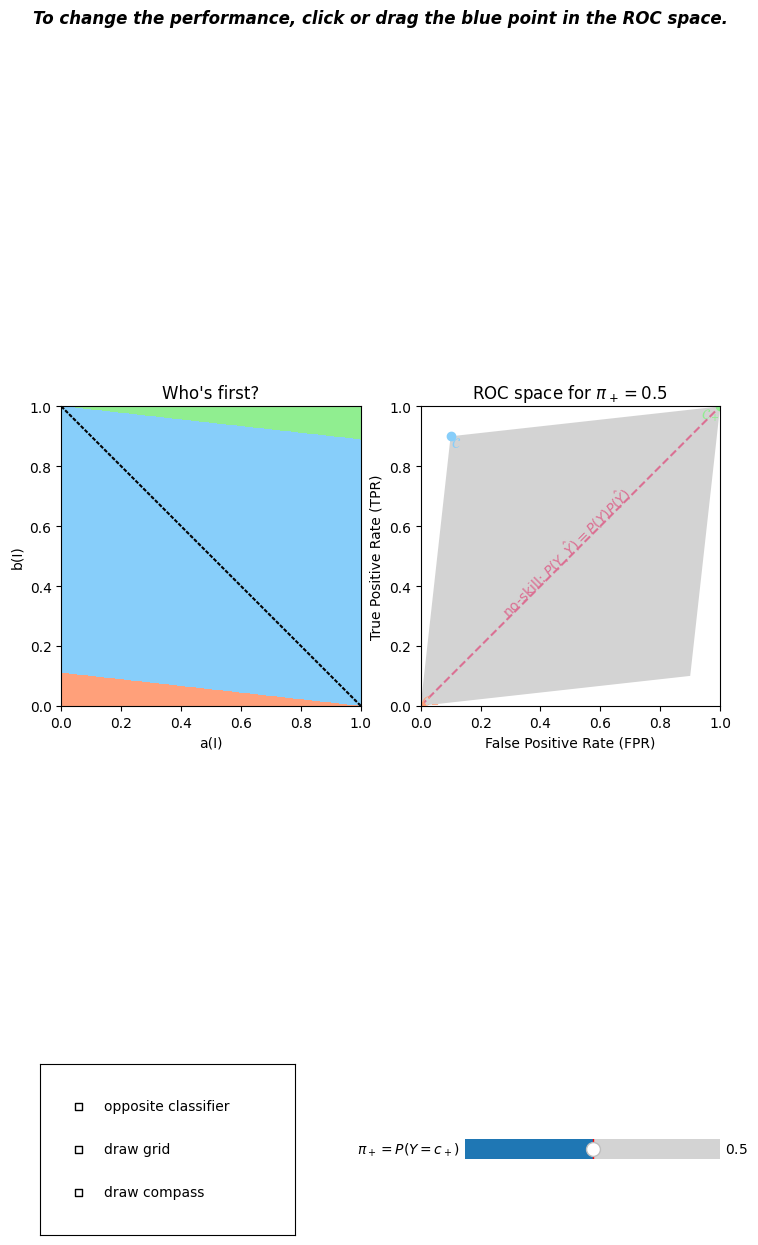

In [8]:
fig